Part 1 (Duplicates)

In [205]:
import pandas as pd
import seaborn as sns
import numpy as np
df = pd.read_csv("data/tacoma_houses.csv",low_memory=False)
df.duplicated().sum()

0

Explanation: The duplicated() function was used to identify duplicate rows in the dataset, and the results showed that there were no duplicate rows. Therefore, no rows were removed during the duplicate cleaning process.

In [206]:
df[df.duplicated(subset=["Latitude", "Longitude", "beds", "price"], keep=False)]
df[df.duplicated(subset=["Latitude", "Longitude", "beds", "price"], keep=False)] \
.groupby(["Latitude", "Longitude", "beds", "price"]).size() \
.sort_values(ascending=False)

Latitude   Longitude    beds    price      
47.224887  -122.431656  4 Beds  $540,000       3
47.113106  -122.408828  4 Beds  $564,950       2
47.264263  -122.346022  4 Beds  $975,000       2
47.248507  -122.487954  4 Beds  $538,000       2
47.251964  -122.496966  4 Beds  $535,000       2
47.253215  -122.497653  2 Beds  $487,500       2
47.254236  -122.497260  2 Beds  $501,000       2
47.257834  -122.458513  3 Beds  $450,000       2
47.261143  -122.335718  2 Beds  $439,000       2
47.261570  -122.491097  2 Beds  $466,000       2
47.266188  -122.491473  4 Beds  $730,000       2
47.243720  -122.544548  4 Beds  $819,000       2
47.270704  -122.511396  3 Beds  $635,000       2
47.274662  -122.506139  3 Beds  $485,000       2
47.275097  -122.493267  4 Beds  $730,000       2
47.276351  -122.508174  3 Beds  $710,000       2
47.284373  -122.520744  3 Beds  $560,000       2
47.300871  -122.409941  4 Beds  $760,000       2
47.303190  -122.416335  3 Beds  $820,000       2
47.307781  -122.430267  5

Explanation: Here is the additional analysis showed repeated combinations of housing features include ("Latitude", "Longitude", "beds", "price"). However, they do not represent exact duplicate rows and were not removed during Part 1 cleaning.

Part 2 (Initial Data Cleaning Plan)
Variable 1: Longitude - Longitude represents the location of a house. Location can strongly impact a house’s price.
Variable 2: Latitude - Latitude represents the location of a house. Location can strongly impact a house’s price.
Variable 3: Price - Price is the key variable used to determine the value of a house and is the main target for analysis.
Variable 4: Beds - The number of bedrooms represents the size of the house, and larger homes with more bedrooms typically have higher market values.
Variable 5: County - The different county can lead to different houses's price
Variable 6: Bathroom - The number of bathrooms also impacts a house’s price because more bathrooms increase convenience and usability for residents.
Variable 7: House size(square footage) - The size of house affects the price of a home because larger houses are generally more expensive than smaller ones.
Variable 8: Address - Exact location of the property. Location is a major driver of price differences.
Variable 9: Year Built - It has an impact on price because newer homes frequently require less maintenance and may feature modern designs and materials.
Variable 10: HOA Fees - The payment of Homeowners Association for maintaining shared community areas and services.
Variable 11: Sewer - It influences housing prices because public sewer systems are generally more convenient and require less maintenance than septic systems.
Variable 12: Living Area - The living area is important because it defines the usable indoor space where people actually live inside the house.
Variable 13: Public Remarks - The detail descriptions of the house, includes property’s features, condition, and selling points that may influence its price
Variable 14: MLS Area - This is important because it captures neighborhood characteristics such as quality, school district, safety, and distance to amenities, all of which can influence a house’s price.
Variable 15: Lot size square feet - The total land area of a property. Larger lots can increase a house’s value due to greater outdoor space, privacy, and development potential.
Variable 16: Appliances - This includes household equipment such as refrigerators, dishwashers, ovens, and washers/dryers. That can increase the house's price because they improve convenience and reduce setup costs for buyers.
Variable 17: Parking Features - This can increase a house’s value because they provide convenient and secure parking options, such as garages, driveways, or covered parking, which are important to many buyers.
Variable 18: Site features - Property amenities, such as fencing, patios, decks, internet access, irrigation systems, or utility hookups can increase the house's price because it's convenience.
Variable 19: Cooling - This can affect a house’s price because more efficient or modern cooling systems improve comfort and reduce energy costs.
Variable 20: Heating - This can affect a house’s price because more efficient or modern heating systems improve comfort and reduce energy costs.

In [207]:
df.isna().sum().sort_values(ascending=False)

Exterior Description    4508
ListingTerms            4508
Legal Description       4508
VA loan                 4508
Disclosures             4508
                        ... 
Total Bedrooms             0
City                       0
Full Baths                 0
url                        0
Longitude                  0
Length: 190, dtype: int64

In [208]:
selected_cols = [
    "Latitude",
    "Longitude",
    "price",
    "County",
    "beds",
    "Bathrooms",
    "house_size",
    "Living Area",
    "Lot Size Square Feet",
    "address",
    "MLS Area",
    "Year Built",
    "HOA Fee",
    "Appliances",
    "Sewer",
    "Cooling",
    "Heating",
    "Public Remarks",
    "Parking Features",
    "Site Features"
]

df_selected = df[selected_cols]
df_selected.head(20)

,Latitude,Longitude,price,County,beds,Bathrooms,house_size,Living Area,Lot Size Square Feet,address,MLS Area,Year Built,HOA Fee,Appliances,Sewer,Cooling,Heating,Public Remarks,Parking Features,Site Features
0,47.253662,-122.501020,"$280,000",Pierce,2 Beds,1.00,800 SQFT,NaN,"21,000 sqft","722 S Mullen\nTacoma, WA 98405",26 - Central Tacoma,1950,NaN,NaN,Sewer Connected,NaN,Baseboard,Seller is an Estate. Buyer purchased As is. Te...,Attached Garage,Fenced-Partially
1,47.135711,-122.447555,"$530,000",Pierce,3 Beds,2.50,"1,944 SQFT",NaN,"9,951 sqft","13322 9th Avenue Ct S\nTacoma, WA 98444",69 - Parkland,2018,NaN,"Dishwasher(s), Dryer(s), Disposal, Microwave(s...",Sewer Connected,NaN,"90%+ High Efficiency, Forced Air, Tankless Wat...",Don't miss this beautiful home in the Tallenti...,"Driveway, Attached Garage","Cable TV, Electric Car Charging, Fenced-Fully,..."
2,47.091209,-122.381868,"$585,950",Pierce,4 Beds,2.25,"1,916 SQFT",NaN,6007,"18201 35th Avenue Ct E\nTacoma, WA 98446",99 - Spanaway,2025,$85,"Dishwasher(s), Disposal, Dryer(s), Microwave(s...",Sewer Connected,Heat Pump,"90%+ High Efficiency, Forced Air, Heat Pump","The Preserve, nestled in the Fredrickson area ...",Attached Garage,"Cable TV, Deck, Electric Car Charging, Fenced-..."
3,47.285087,-122.369776,"$530,000",Pierce,3 Beds,2.50,"1,436 SQFT","1,436 sqft","5,750 sqft","3111 58th Avenue NE\nTacoma, WA 98422",94 - Browns Point,1989,$0,"Dishwasher(s), Disposal, Refrigerator(s), Stov...",Sewer Connected,NaN,Forced Air,Beautifully updated basement rambler with alle...,"Attached Garage, Off Street","Deck, Fenced-Fully"
4,47.286240,-122.517141,"$475,000",Pierce,3 Beds,1.00,951 SQFT,NaN,"6,444 sqft","6010 N 41st Street\nTacoma, WA 98407",25 - North Tacoma,1982,$0,"Dishwasher(s), Dryer(s), Refrigerator(s), Stov...",Sewer Connected,NaN,Baseboard,"Charming 3-bedroom, 1-bath home in a prime Nor...",Attached Garage,"Fenced-Fully, High Speed Internet"
5,47.314928,-122.430700,"$1,500,000",Pierce,3 Beds,2.50,"3,580 SQFT","3,580 sqft","35,000 sqft","8204 East Side Drive NE\nTacoma, WA 98422",94 - Browns Point,1996,$0,"Dishwasher(s), Dryer(s), Microwave(s), Refrige...",Septic Tank,Heat Pump,"90%+ High Efficiency, Forced Air, Heat Pump, S...",Unobstructed Sound and mountain views highligh...,"Driveway, Attached Garage, Off Street","Cable TV, Deck, Gas Available, High Speed Inte..."
6,47.208383,-122.412233,"$569,900",Pierce,5 Beds,3.00,"1,810 SQFT",NaN,2520,"5318 E M Street\nTacoma, WA 98404",61 - Southeast Tacoma,2024,NaN,"Dishwasher(s), Dryer(s), Disposal, Microwave(s...",Sewer Connected,"90%+ High Efficiency, Central A/C, Forced Air,...","90%+ High Efficiency, Forced Air, Heat Pump, H...",Find abundant space at an exceptional value in...,"Driveway, Attached Garage","Cable TV, Electric Car Charging, Fenced-Fully,..."
7,47.292824,-122.518687,"$925,000",Pierce,5 Beds,2.25,"2,493 SQFT",NaN,"9,240 sqft","4658 N Defiance Street\nTacoma, WA 98407",13 - North Tacoma,1921,$0,"Dishwasher(s), Refrigerator(s), Stove(s)/Range(s)",Sewer Connected,Ductless,"Ductless, Wall Unit(s)",Welcome to this North End sanctuary located wa...,"Driveway, Detached Garage, Off Street","Fenced-Fully, Outbuildings, Shop"
8,47.286981,-122.519019,"$634,000",Pierce,4 Beds,1.75,"1,530 SQFT",NaN,"7,550 sqft","6108 N 42nd Street\nTacoma, WA 98407",25 - North Tacoma,1979,NaN,"Dishwasher(s), Microwave(s), Stove(s)/Range(s)",Sewer Connected,NaN,Forced Air,Live the Dream in Tacoma’s North End! Centrall...,"Driveway, Attached Garage, Off Street","Fenced-Partially, Gas Available, Patio"
9,47.291230,-122.390962,"$809,250",Pierce,4 Beds,2.50,"2,396 SQFT","2,396 sqft","9,050 sqft","3914 fairwood Boulevard NE\nTacoma, WA 98422",94 - Browns Point,1997,$440,"Dishwasher(s), Disposal, Microwave(s), Refrige...",Sewer Connected,Forced Air,Forced Air,Stunning NE Tacoma Remodel with Views! Nestled...,Attached Garage,"Gas Available, Patio, Sprinkler System"


In [209]:
df[["Latitude",
    "Longitude",
    "price",
    "County",
    "beds",
    "Bathrooms",
    "house_size",
    "Living Area",
    "Lot Size Square Feet",
    "address",
    "MLS Area",
    "Year Built",
    "HOA Fee",
    "Appliances",
    "Sewer",
    "Cooling",
    "Heating",
    "Public Remarks",
    "Parking Features",
    "Site Features"]].isnull().sum()

Latitude                   0
Longitude                  0
price                      0
County                     0
beds                       0
Bathrooms                  1
house_size                 0
Living Area             3553
Lot Size Square Feet       3
address                    0
MLS Area                   0
Year Built                 0
HOA Fee                 1506
Appliances               342
Sewer                     36
Cooling                 2387
Heating                  151
Public Remarks           123
Parking Features          91
Site Features            489
dtype: int64

In [210]:
df["Bathrooms"] = df["Bathrooms"].fillna(df["Bathrooms"].median())
df["Bathrooms"].isnull().sum()

0

In [211]:
df["Lot Size Square Feet"] = (
    df["Lot Size Square Feet"].str.replace("sqft", "")
    .str.replace(",", "")
    .str.strip()
    .astype("float")
)
df["Lot Size Square Feet"]
df["Lot Size Square Feet"] = df["Lot Size Square Feet"].fillna(
    df["Lot Size Square Feet"].median()
)
df["Lot Size Square Feet"].isnull().sum()

0

In [144]:
df["Sewer"] = df["Sewer"].fillna(df["Sewer"].mode()[0])
df["Sewer"].isnull().sum()

0

In [212]:
df = df.drop(columns=['Living Area'])
print('Living Area' in df.columns)

False


In [213]:
df["HOA Fee"] = (
    df["HOA Fee"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
    .astype(float)
)
df["HOA Fee"] = df["HOA Fee"].fillna(0)
df["HOA Fee"].isnull().sum()

0

In [214]:
df["Cooling"] = df["Cooling"].fillna("None")
df["Cooling"].isnull().sum()

0

In [215]:
df["Appliances"] = df["Appliances"].fillna("None")
df["Appliances"].isnull().sum()

0

In [216]:
df["Heating"] = df["Heating"].fillna("Not Listed")
df["Heating"].isnull().sum()

0

In [217]:
df["Public Remarks"] = df["Public Remarks"].fillna("Not Listed")
df["Public Remarks"].isnull().sum()

0

In [218]:
df = df.dropna(subset=["Parking Features"])
df["Parking Features"].isnull().sum()

0

In [219]:
df["Site Features"] = df["Site Features"].fillna("Not Listed")
df["Site Features"].isnull().sum()

0

In [220]:
df["house_size"] = (
    df["house_size"].str.replace(" SQFT", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
    .astype("float")
)
df["house_size"]

0        800.0
1       1944.0
2       1916.0
3       1436.0
4        951.0
         ...  
4504    1536.0
4505    2134.0
4506    1902.0
4507    1800.0
4508    3601.0
Name: house_size, Length: 4418, dtype: float64

In [221]:
df["beds"] = (
    df['beds'].str.replace(" Beds", "", regex=False)
    .str.replace(" Bed", "", regex=False)
    .str.strip()
    .astype("int")
)
df["beds"]

0       2
1       3
2       4
3       3
4       3
       ..
4504    3
4505    3
4506    4
4507    4
4508    4
Name: beds, Length: 4418, dtype: int64

In [228]:
df["price"] = (
    df["price"].str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
    .astype("float")
)
df["price"]

0        280000.0
1        530000.0
2        585950.0
3        530000.0
4        475000.0
          ...    
4504     530000.0
4505     592000.0
4506     520000.0
4507     332500.0
4508    1950000.0
Name: price, Length: 4418, dtype: float64

In [222]:
variables = [
    'Latitude', 'Longitude', 'price', 'County', 'beds',
    'Bathrooms', 'house_size', 'Lot Size Square Feet',
    'address', 'MLS Area', 'Year Built', 'HOA Fee',
    'Appliances', 'Sewer', 'Cooling', 'Heating',
    'Public Remarks', 'Parking Features', 'Site Features'
]

print(df[variables].dtypes)

Latitude                float64
Longitude               float64
price                    object
County                   object
beds                      int64
Bathrooms               float64
house_size              float64
Lot Size Square Feet    float64
address                  object
MLS Area                 object
Year Built                int64
HOA Fee                 float64
Appliances               object
Sewer                    object
Cooling                  object
Heating                  object
Public Remarks           object
Parking Features         object
Site Features            object
dtype: object


In [223]:

df["Sewer"] = df["Sewer"].str.lower().str.strip()
sewer_map = {
    "sewer connected": "Sewer Connected",
    "publicsewer": "Sewer Connected",
    "step sewer": "Sewer Connected",
    "available": "Available",
    "septic tank": "Septic Tank"
}

df["Sewer"] = df["Sewer"].replace(sewer_map)
df.loc[df["Sewer"].str.contains("sewer connected", na=False), "Sewer"] = "Sewer Connected"
df.loc[df["Sewer"].str.contains("septic tank", na=False), "Sewer"] = "Septic Tank"
df.loc[df["Sewer"].str.contains("available", na=False), "Sewer"] = "Available"
df["Sewer"].str.lower().value_counts()

Sewer
sewer connected    3885
septic tank         409
available            90
Name: count, dtype: int64

In [224]:
df["Cooling"] = df["Cooling"].str.lower().str.strip()

df.loc[df["Cooling"].str.contains("central a/c|central ac", na=False), "Cooling"] = "Central AC"
df.loc[df["Cooling"].str.contains("heat pump", na=False), "Cooling"] = "Heat Pump"
df.loc[df["Cooling"].str.contains("forced air", na=False), "Cooling"] = "Forced Air"
df.loc[df["Cooling"].str.contains("ductless|mini split", na=False), "Cooling"] = "Ductless Mini Split"
df.loc[df["Cooling"].str.fullmatch("none", na=False), "Cooling"] = "None"

main_categories = [
    "Central AC",
    "Heat Pump",
    "Forced Air",
    "Ductless Mini Split",
    "None"
]

def map_cooling(x):
    if x in main_categories:
        return x
    return "Other"

df["Cooling"] = df["Cooling"].apply(map_cooling)
df["Cooling"].str.lower().value_counts()

Cooling
none                   2319
central ac              729
heat pump               497
ductless mini split     382
forced air              323
other                   168
Name: count, dtype: int64

In [263]:
df["Heating"] = df["Heating"].str.lower().str.strip()

df.loc[df["Heating"].str.contains("forced air", na=False), "Heating"] = "Forced Air"
df.loc[df["Heating"].str.contains("baseboard", na=False), "Heating"] = "Baseboard"
df.loc[df["Heating"].str.contains("wall unit", na=False), "Heating"] = "Wall Unit"
df.loc[df["Heating"].str.contains("heat pump", na=False), "Heating"] = "Heat Pump"
df.loc[df["Heating"].str.contains("ductless|mini split|minisplit", na=False), "Heating"] = "Ductless Mini Split"

main_categories = [
    "Forced Air",
    "Baseboard",
    "Wall Unit",
    "Heat Pump",
    "Ductless Mini Split"
]

def map_heating(x):
    if x in main_categories:
        return x
    return "Other"

df["Heating"] = df["Heating"].apply(map_heating)

df["Heating"].value_counts()
df["Heating"].str.lower().value_counts()

Heating
forced air             2864
baseboard               554
wall unit               450
other                   258
heat pump               170
ductless mini split     122
Name: count, dtype: int64

In [225]:
df["Parking Features"] = df["Parking Features"].str.lower().str.strip()

df.loc[df["Parking Features"].str.contains("attached garage", na=False), "Parking Features"] = "Attached Garage"
df.loc[df["Parking Features"].str.contains("detached garage", na=False), "Parking Features"] = "Detached Garage"
df.loc[df["Parking Features"].str.contains("driveway", na=False), "Parking Features"] = "Attached Garage"
df.loc[df["Parking Features"].str.contains("off street", na=False), "Parking Features"] = "Off Street Parking"

main_categories = [
    "Attached Garage",
    "Detached Garage",
    "Off Street Parking",
]

df["Parking Features"] = df["Parking Features"].apply(
    lambda x: x if x in main_categories else "Other"
)
df["Parking Features"].str.lower().value_counts()

Parking Features
attached garage       2712
detached garage       1269
off street parking     290
other                  147
Name: count, dtype: int64

In [183]:
df_clean = df.drop(columns=[
    "address",
    "Public Remarks",
    "Site Features",
    "Appliances"
], inplace=True)

Those variables were removed because they have lots of many categories and too messy text columns for clean encoding. 

Part 3 (Implement Data Cleaning Plan)

In [226]:
selected_cols = [
    "Latitude",
    "Longitude",
    "price",
    "County",
    "beds",
    "Bathrooms",
    "house_size",
    "Lot Size Square Feet",
    "MLS Area",
    "Year Built",
    "HOA Fee",
    "Sewer",
    "Cooling",
    "Heating",
    "Parking Features"
]

df_selected = df[selected_cols]
df_selected.head(20)

,Latitude,Longitude,price,County,beds,Bathrooms,house_size,Lot Size Square Feet,MLS Area,Year Built,HOA Fee,Sewer,Cooling,Heating,Parking Features
0,47.253662,-122.501020,"$280,000",Pierce,2,1.00,800.0,21000.0,26 - Central Tacoma,1950,0.0,Sewer Connected,None,Baseboard,Attached Garage
1,47.135711,-122.447555,"$530,000",Pierce,3,2.50,1944.0,9951.0,69 - Parkland,2018,0.0,Sewer Connected,None,"90%+ High Efficiency, Forced Air, Tankless Wat...",Attached Garage
2,47.091209,-122.381868,"$585,950",Pierce,4,2.25,1916.0,6007.0,99 - Spanaway,2025,85.0,Sewer Connected,Heat Pump,"90%+ High Efficiency, Forced Air, Heat Pump",Attached Garage
3,47.285087,-122.369776,"$530,000",Pierce,3,2.50,1436.0,5750.0,94 - Browns Point,1989,0.0,Sewer Connected,None,Forced Air,Attached Garage
4,47.286240,-122.517141,"$475,000",Pierce,3,1.00,951.0,6444.0,25 - North Tacoma,1982,0.0,Sewer Connected,None,Baseboard,Attached Garage
5,47.314928,-122.430700,"$1,500,000",Pierce,3,2.50,3580.0,35000.0,94 - Browns Point,1996,0.0,Septic Tank,Heat Pump,"90%+ High Efficiency, Forced Air, Heat Pump, S...",Attached Garage
6,47.208383,-122.412233,"$569,900",Pierce,5,3.00,1810.0,2520.0,61 - Southeast Tacoma,2024,0.0,Sewer Connected,Central AC,"90%+ High Efficiency, Forced Air, Heat Pump, H...",Attached Garage
7,47.292824,-122.518687,"$925,000",Pierce,5,2.25,2493.0,9240.0,13 - North Tacoma,1921,0.0,Sewer Connected,Ductless Mini Split,"Ductless, Wall Unit(s)",Detached Garage
8,47.286981,-122.519019,"$634,000",Pierce,4,1.75,1530.0,7550.0,25 - North Tacoma,1979,0.0,Sewer Connected,None,Forced Air,Attached Garage
9,47.291230,-122.390962,"$809,250",Pierce,4,2.50,2396.0,9050.0,94 - Browns Point,1997,440.0,Sewer Connected,Forced Air,Forced Air,Attached Garage


In [184]:
df[["Latitude",
    "Longitude",
    "price",
    "County",
    "beds",
    "Bathrooms",
    "house_size",
    "Lot Size Square Feet",
    "MLS Area",
    "Year Built",
    "HOA Fee",
    "Sewer",
    "Cooling",
    "Heating",
    "Parking Features"]].isnull().sum()

Latitude                0
Longitude               0
price                   0
County                  0
beds                    0
Bathrooms               0
house_size              0
Lot Size Square Feet    0
MLS Area                0
Year Built              0
HOA Fee                 0
Sewer                   0
Cooling                 0
Heating                 0
Parking Features        0
dtype: int64

Explanation: After completing the data cleaning process, 15 variables remained out of the original 20. These variables represent the most relevant and usable features for analysis, including numeric housing characteristics such as price, latitude, longitude, bedrooms, bathrooms, house size, lot size, year built, and HOA fee, as well as standardized categorical variables such as county, MLS area, heating type, cooling type, sewer type, and parking features. In addition, variables such as address, appliances, public remarks, and site features were removed because they contained unstructured text data, a large number of unique categories, and high levels of missing values (over 60%), making them unsuitable for clean encoding and numerical analysis. These steps ensured that the final dataset is suitable for statistical analysis.

Part 1 (Univariate Distributions)

1. Create a visualization of the response variable. Determine if any transformation should be applied to the response to make the data look more "normal".

<Axes: xlabel='log_price', ylabel='Count'>

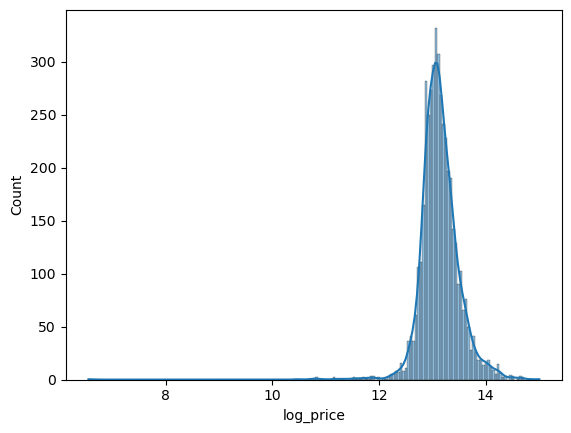

In [229]:
df["log_price"] = np.log(df["price"])
sns.histplot(data=df, x="log_price", kde=True)


2. Create visualizations to investigate the distributions of other predictor variables you intend to use in the model. For each variable, consider the following questions:
A. Do there appear to be outliers?
B. Are there any erroneous or impossible values (e.g., negative house prices, an unrealistic number of bedrooms/bathrooms, etc.)?
C. For categorical variables, should categories be combined? Are there duplicate categories (i.e., same category, different name)?
D. Are there any other interesting features about the variable that should be taken into account when modeling?

<Axes: xlabel='beds'>

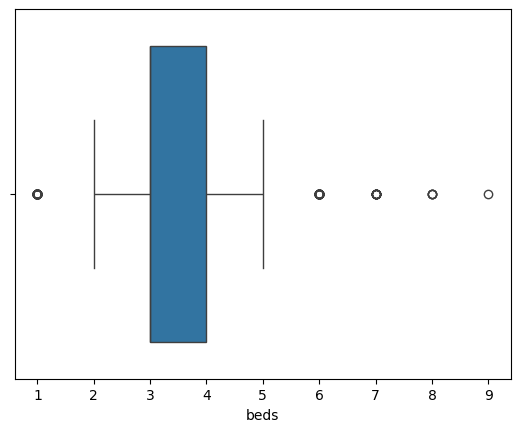

In [233]:
sns.boxplot(data=df, x="beds")

A. Yes, the outlier appears in the beds variable. Low is 1 bedroom and high is 6 to 9 bedrooms.
B. The house with 9 bedrooms are not usual but not impossible.
D.  The distribution is right-skewed, with most homes having 3 bedrooms. The small number of homes with 6–9 bedrooms causes the right skew in the chart.

<Axes: xlabel='Bathrooms'>

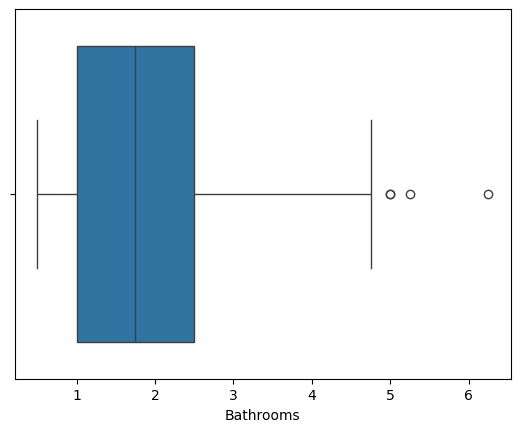

In [236]:
sns.boxplot(data=df, x="Bathrooms")

A. Yes, the outlier appears in the bathrooms variable. With three open circles, which means home with 5 or 6 bathrooms.
B. Homes with 5 or 6 bathrooms might be large homes, because typical homes usually have 2 to 4 bathrooms.
D. The small number of homes with 5 to 6 bathrooms causes a slight right skew, but most homes have 1 or 2 bathrooms.

<Axes: xlabel='house_size', ylabel='Count'>

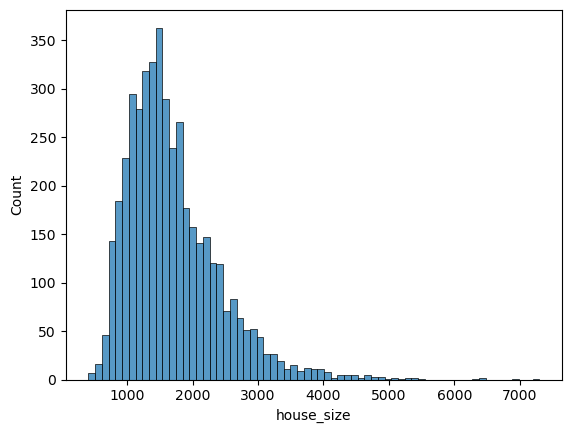

In [240]:
sns.histplot(data=df, x="house_size")

A. Yes, the outlier appears in the house size variable. With lots of open circles after the upper whisker.
B. Homes with a house size as large as 7,000 sq ft do exist but are not usual.
D. The distribution is right-skewed. A log transformation of house_size could help balance the skew.

<Axes: xlabel='Longitude', ylabel='Count'>

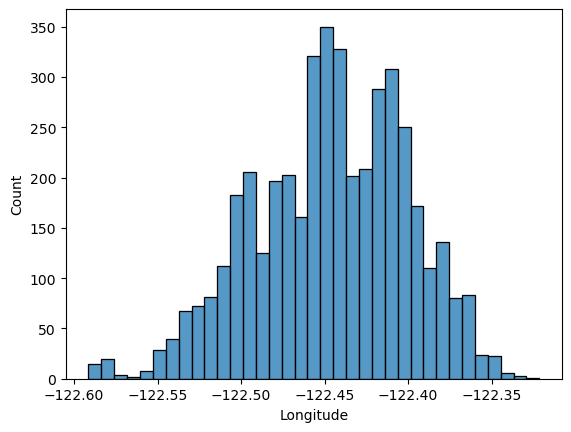

In [245]:
sns.histplot(data=df, x="Longitude")

A. Yes, the outlier appears in the longitude variable beyond the left whisker.
B. These are not erroneous values. 
D. The distribution is slightly left-skewed. The outlier on the left represent homes in a more western location.

<Axes: xlabel='Latitude'>

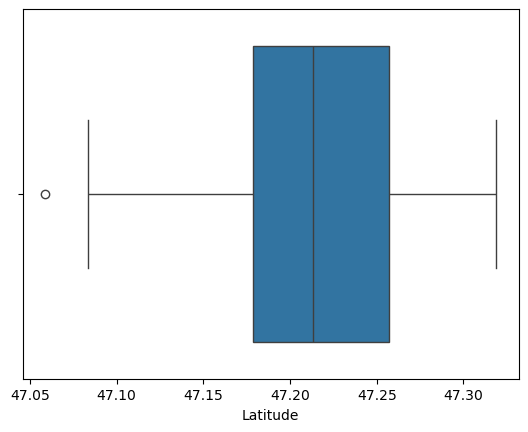

In [247]:
sns.boxplot(data=df, x="Latitude")

A. Yes, the outlier appears in the latitude variable beyond the left whisker.
B. These are not erroneous values. 
D. The distribution is slightly left-skewed. The outlier on the left represent homes in a more southern location.

<Axes: xlabel='Lot Size Square Feet'>

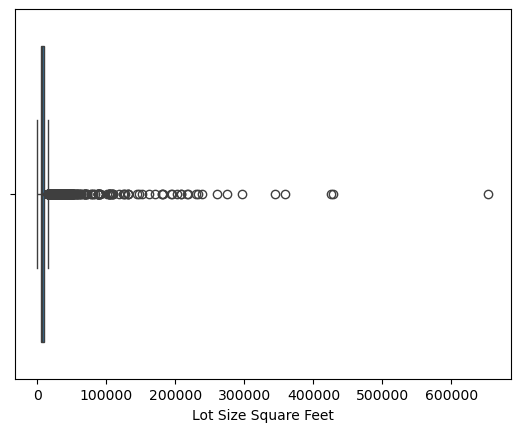

In [250]:
sns.boxplot(data=df, x="Lot Size Square Feet")

A. Yes, the outlier appears in the lot size square feet variable. There are a lot of circle open in the right side.
B.  Lot sizes of 500,000 to 600,000 sq ft are very large but still possible, they could represent rural properties or estates.
D. The distribution is strongly right-skewed, with many outliers on the right side. A log transformation could help balance the skew.

<Axes: xlabel='Year Built'>

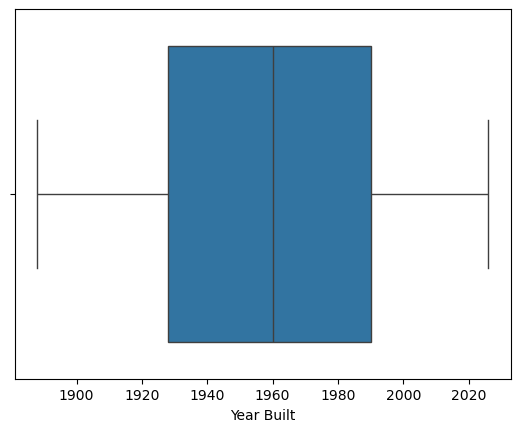

In [253]:
sns.boxplot(data=df, x="Year Built")

A. No outlier appears in the year built variable.
B. These are not erroneous values. The year built values are within a normal range.
D. The distribution looks clean and is ready for modeling.

<Axes: xlabel='HOA Fee'>

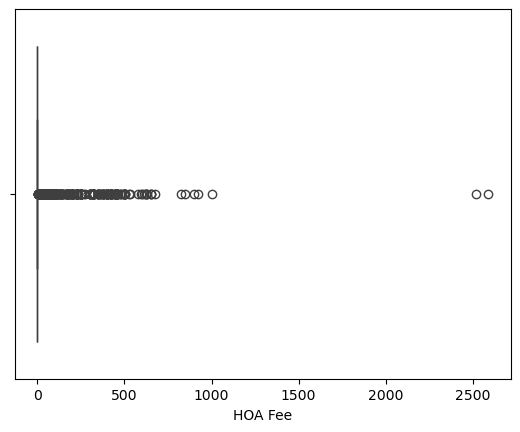

In [254]:
sns.boxplot(data=df, x="HOA Fee")

A. Yes, the outlier appears in the HOA fee variable. There are a lot of circle open in the right side.
B. The HOA fees look very high, but they could belong to luxury communities, so these values seem possible.
D.  The distribution is strongly right-skewed, with many high fee outliers on the right side. A log transformation could be used to help balance the skew.

<Axes: xlabel='County', ylabel='count'>

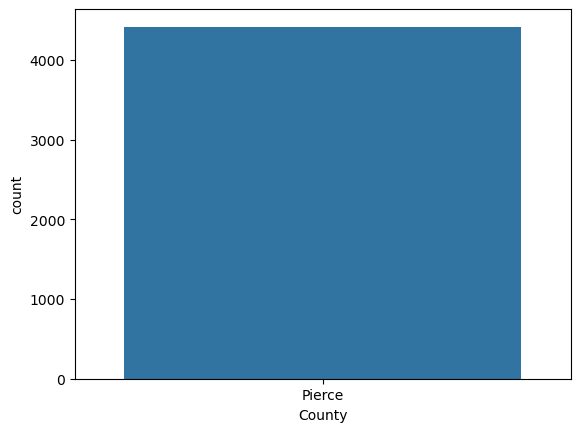

In [255]:
sns.countplot(data=df, x="County")

A. No outlier beacause this is  a categorical variable.
B. These are not erroneous values. The data is entirely from Pierce County.
C. This variable shows only one county, so it has no variety for predicting house prices and can be dropped.
D. There is no difference in this distribution, it show only one categorical so it might be dropped because it cannot explain for any difference in houses price.

<Axes: xlabel='MLS Area', ylabel='count'>

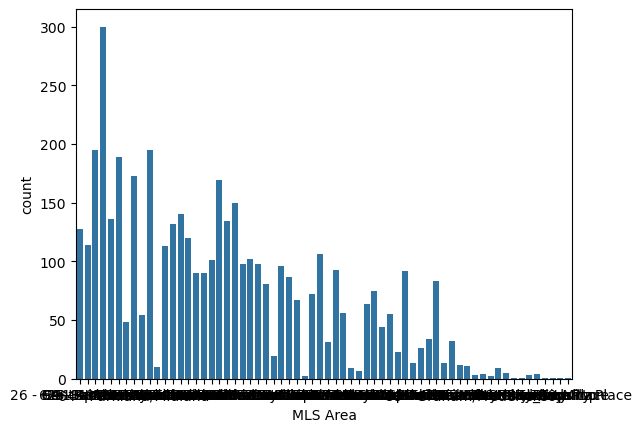

In [258]:
sns.countplot(data=df, x="MLS Area")

A. No outlier beacause this is  a categorical variable.
B. These are not erroneous values. 
C. This variable has many categories. It may need further cleaning before modeling, or could be dropped or combined if there are too many unique values, which can make modeling harder.
D. This distribution is not balance which could affect model performance. 

<Axes: xlabel='Sewer', ylabel='count'>

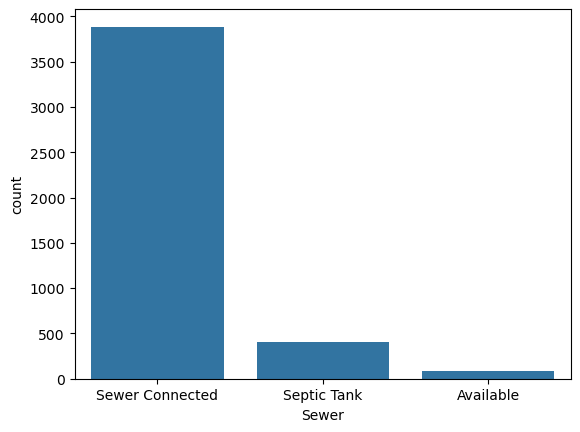

In [259]:
sns.countplot(data=df, x="Sewer")

A. No outlier beacause this is  a categorical variable.
B. These are not erroneous values. 
C. The chart shows 3 categories and they can be kept as is. So combining is not necessary here.
D. The distribution is maily in sewer connected catergory, so it is imbalanced but it would still show differences when predicting the house prices.

<Axes: xlabel='Cooling', ylabel='count'>

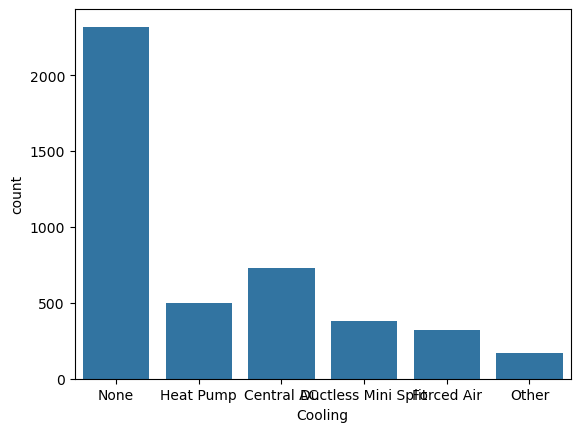

In [260]:
sns.countplot(data=df, x="Cooling")

A. No outlier beacause this is  a categorical variable.
B. These are not erroneous values. 
C. The distribution has 6 different categories and combining is not necessary before modeling.
D. The most common category is None, but homes with cooling systems would likely be more expensive than homes with no cooling.

<Axes: xlabel='Heating', ylabel='count'>

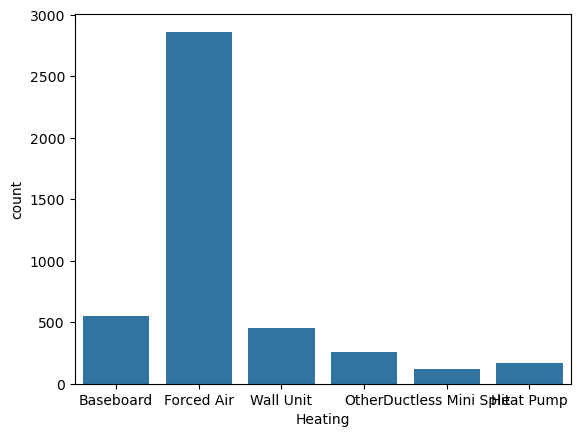

In [265]:
sns.countplot(data=df, x="Heating")

A. No outlier beacause this is  a categorical variable.
B. These are not erroneous values. 
C. The distribution has 6 different categories and combining is not necessary before modeling.
D. The heating type might affect house prices, making the differences among the categories worth considering for modeling.

<Axes: xlabel='Parking Features', ylabel='count'>

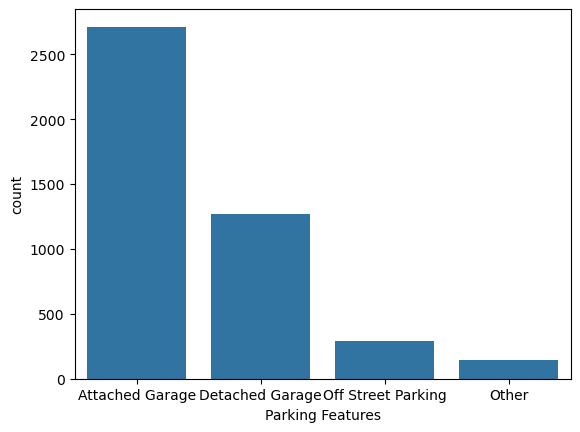

In [266]:
sns.countplot(data=df, x="Parking Features")

A. No outlier beacause this is  a categorical variable.
B. These are not erroneous values. 
C. The distribution has 4 different categories and combining is not necessary before modeling.
D. The distribution shows that homes with an attached garage may have higher prices because it is more convenient.

Part 2 (Relationships Between Variables)
Answer the following questions. Use visualizations or numeric summaries to support your answers:

1. Are there any potential issues with multicollinearity (i.e., are there variables that essentially provide the same information about the response)?
2. Which variables appear to be most strongly related to the response?
3. For quantitative variables, should you transform any of the predictor variables to create more linear relationships with the response?
4. Are there any other interesting patterns or relationships that you want to take into account when modeling?

1. Are there any potential issues with multicollinearity (i.e., are there variables that essentially provide the same information about the response)?

<Axes: >

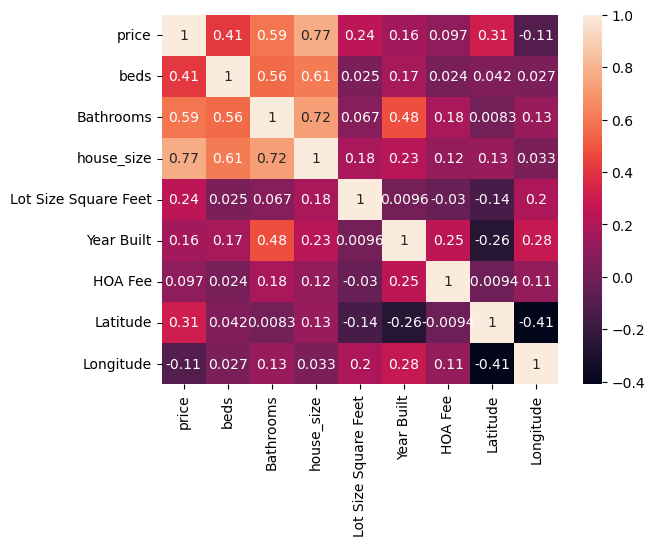

In [271]:
corr_matrix = df[[
    "price", "beds", "Bathrooms", "house_size",
    "Lot Size Square Feet", "Year Built",
    "HOA Fee", "Latitude", "Longitude"
]].corr()

sns.heatmap(corr_matrix, annot=True)



Yes, there are potential issues with multicollinearity. Based on the correlation matrix of numeric variables, bathrooms and house size have the same 0.72, it means both procide kinda similar informations. But go through overall, three variables such as beds, bathrooms, and house size have different way when estimate the size of the house.

2. Which variables appear to be most strongly related to the response?
Based on the correlation matrix of numeric variables, the house size variable is the most strongly related to the price with a correlation of 0.77.

3. For quantitative variables, should you transform any of the predictor variables to create more linear relationships with the response?

<Axes: xlabel='log_price', ylabel='log_house_size'>

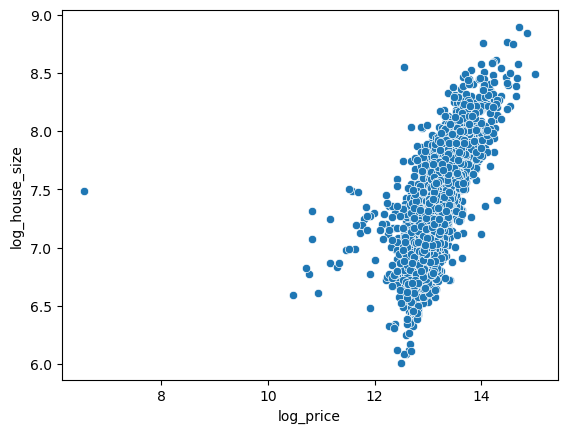

In [277]:
df["log_house_size"] = np.log(df["house_size"])
sns.scatterplot(data=df, x="log_price", y="log_house_size")

After applying the log transformation for house_size and price, the relationship looks more linear. This means that both variables should use the log-transformed versions when building the model.

<Axes: xlabel='log_price', ylabel='log_HOA_fee'>

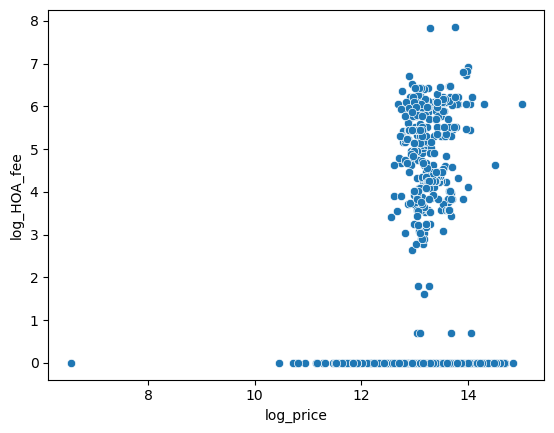

In [280]:
df["log_HOA_fee"] = np.log(df["HOA Fee"]+1)
sns.scatterplot(data=df, x="log_price", y="log_HOA_fee")

After applying a log transformation to HOA fee and price, the relationship between the two variables appears weak and not very linear.

<Axes: xlabel='log_price', ylabel='log_lot_size'>

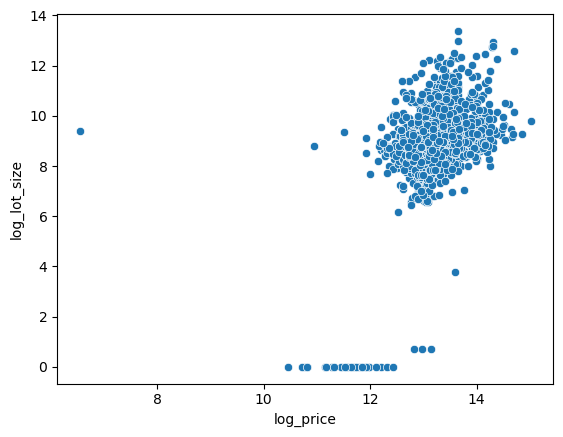

In [282]:
df["log_lot_size"] = np.log(df["Lot Size Square Feet"]+1)
sns.scatterplot(data=df, x="log_price", y="log_lot_size")

After applying a log transformation to Lot Size Square Feet and price, the relationship between the two variables appears weak and not very linear. This means, a bigger lot doesn't mean go with higher price, it also depends on location

/opt/miniconda3/envs/tstat280/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: xlabel='log_price', ylabel='Longitude'>

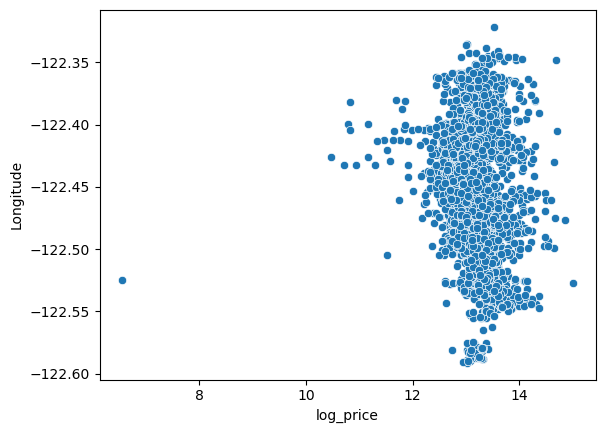

In [286]:
sns.scatterplot(data=df, x="log_price", y="Longitude")

<Axes: xlabel='log_price', ylabel='Latitude'>

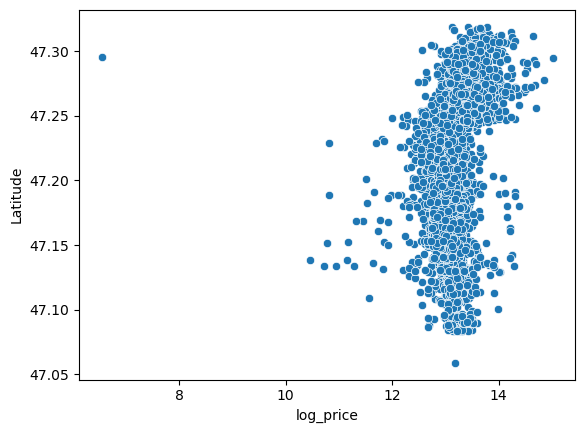

In [287]:
sns.scatterplot(data=df, x="log_price", y="Latitude")

<Axes: xlabel='log_price', ylabel='beds'>

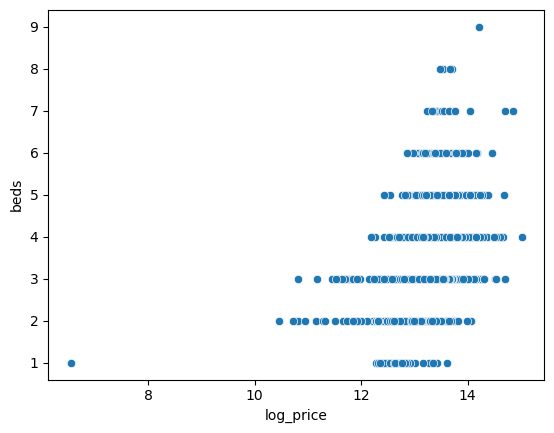

In [288]:
sns.scatterplot(data=df, x="log_price", y="beds")

<Axes: xlabel='log_price', ylabel='Bathrooms'>

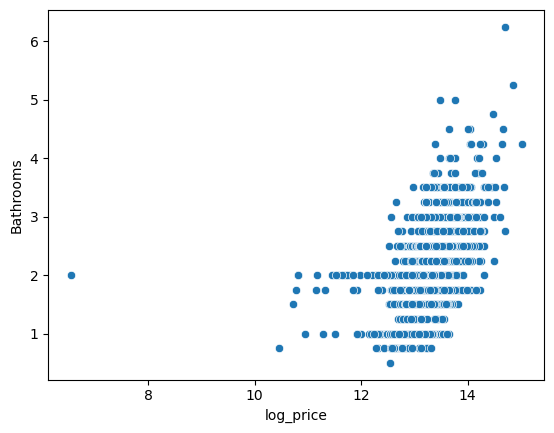

In [289]:
sns.scatterplot(data=df, x="log_price", y="Bathrooms")

<Axes: xlabel='log_price', ylabel='Year Built'>

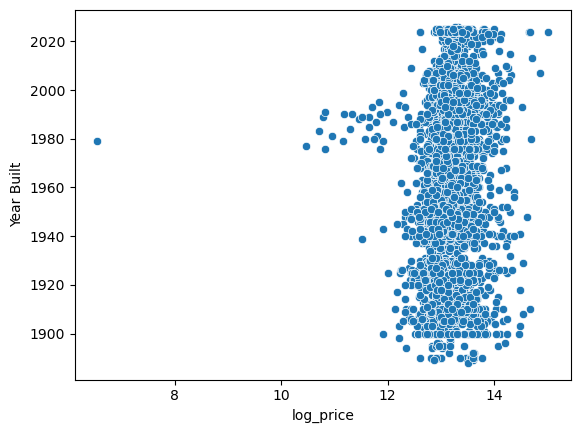

In [291]:
sns.scatterplot(data=df, x="log_price", y="Year Built")

For the variables Longitude, Latitude, beds, Bathrooms, and Year Built, the scatter plots show weak and non-linear relationships with log_price. Since these variables are not heavily skewed, no log transformation is needed and they can be used as is in the model.

4. Are there any other interesting patterns or relationships that you want to take into account when modeling?

<Axes: xlabel='log_price', ylabel='Cooling'>

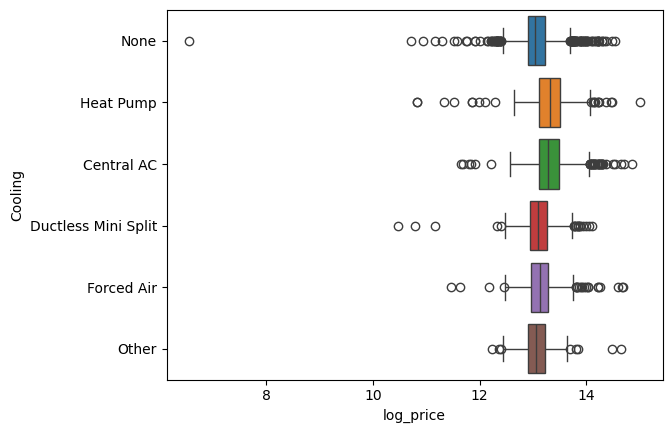

In [293]:
sns.boxplot(data=df, x="log_price", y="Cooling", hue="Cooling")

Homes with no cooling tend to have lower prices than homes with cooling systems. Especially, Central AC is the most expensive cooler among all cooling types in this chart. Therefore, the cooling distribution is a good variable for predicting in the model.

<Axes: xlabel='log_price', ylabel='Heating'>

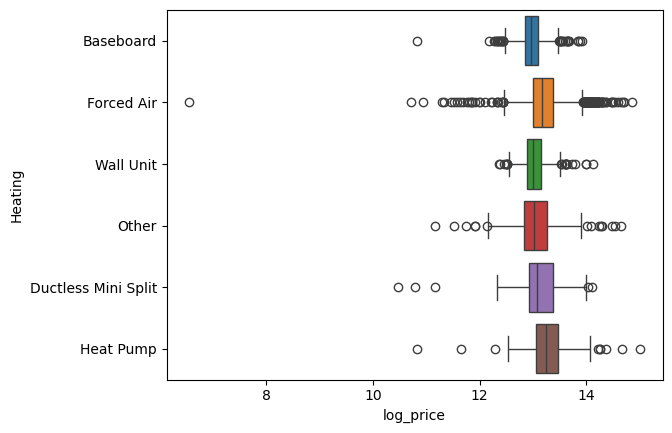

In [294]:
sns.boxplot(data=df, x="log_price", y="Heating", hue="Heating")

Homes with no heating tend to have lower prices than homes with heating systems. Heating type does not show large differences in prices across categories, so it is not a strong predictor for house prices.

<Axes: xlabel='log_price', ylabel='Sewer'>

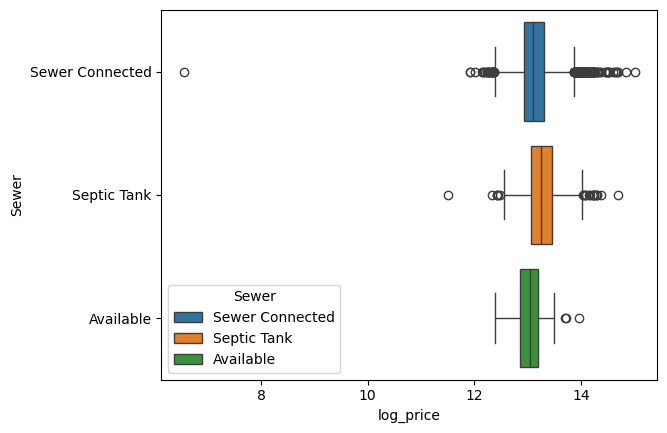

In [296]:
sns.boxplot(data=df, x="log_price", y="Sewer", hue="Sewer")

The realationship between sewer and log_price may be a weak predictor for house prices. The differences between categories are moderate but not very large

<Axes: xlabel='log_price', ylabel='Parking Features'>

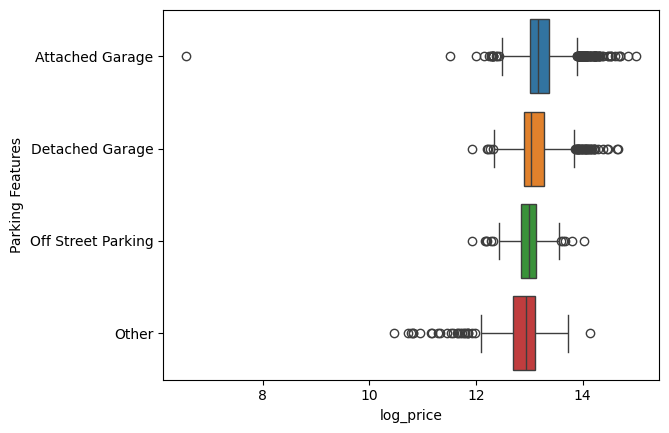

In [297]:
sns.boxplot(data=df, x="log_price", y="Parking Features", hue="Parking Features")


This relationship between the Parking Features and log_price box plot show the most interesting differences. This variable is a good choice for predicting when building model because it shows different price distributions.

<Axes: xlabel='log_price', ylabel='MLS Area'>

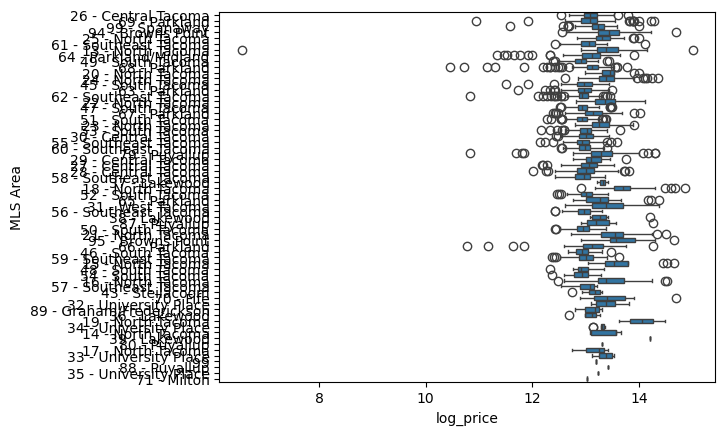

In [299]:
sns.boxplot(data=df, x="log_price", y="MLS Area")

The relationship between MLS Area and log_price shows different prices based on different locations. This is a good variable for predicting house prices in the model.

Part 3 (Feature Engineering)
Now, consider the data found in the tacoma_houses.csv as well as other datasets that have been made available to you.

1. Are there any other features you could create that you believe would be helpful for predicting house prices? These could be derived from the house dataset or could be derived from other data sources.
2. Create a visualization to investigate the relationship between this new feature and the response variable. Does there appear to be a relationship?
 

I picked the Year Built variable to create the house_age by subtracting  taking year in 2026 minus for Year Built of these houses to see.
The relationship between log_price and house_age shows the increase of price in new homes while older homes tend to have lower prices. So this new feature provide useful informations for predicting the house prices. 

<Axes: xlabel='log_price', ylabel='house_age'>

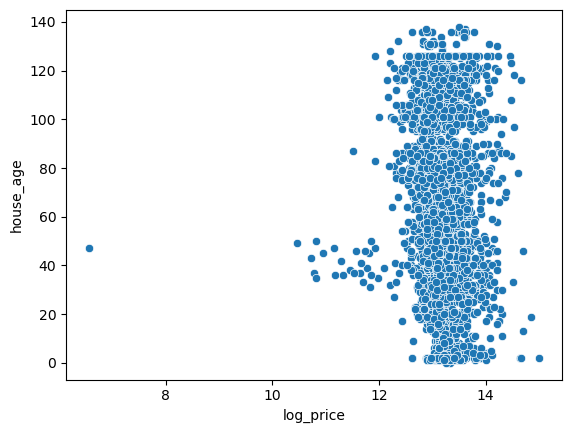

In [308]:
df["house_age"] = 2026 - df["Year Built"]
sns.scatterplot(data=df, x="log_price", y="house_age")

<Axes: xlabel='log_price', ylabel='High School District'>

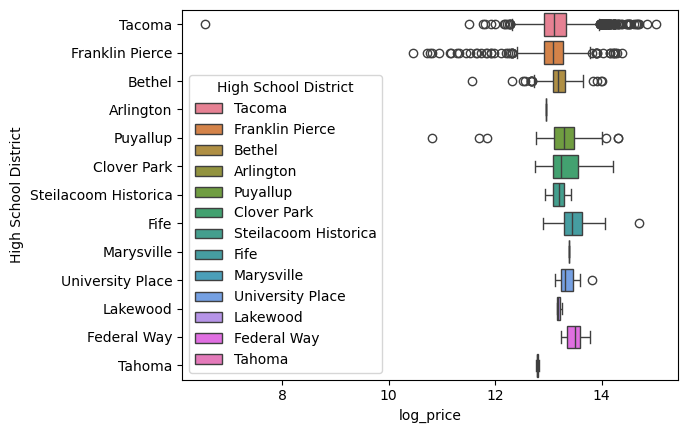

In [312]:
sns.boxplot(data=df, x="log_price", y="High School District", hue="High School District")

I used the High School District variable to predict the house prices. The boxplot chart shows different price distributions across school districts. So, Tacoma and Franklin Pierce have the highest median log_prices and widest spreads. Otherwise, Lakewood, Federal Way, and Tahoma have the lowest median prices. Overall, this new feature is helpful to identify which locations are more desirable and good for predicting the house prices.

# Model Fitting
Using your cleaned up dataset, fit a model to predict house price using the list of predictors you previously selected. Then do the following:

## Make note of any errors you ran into when trying to fit the model for the first time.
ERROR: could not convert string to float for the dataset contained categorical variables such as County, MLS Area, Heating, Cooling, Sewer, and Parking Features.
## Address these errors so that you can fit the model successfully.
Using pd.get_dummies() to convert all categorical variables to numeric variables
## Once the model has been fit successfully, take note of the RMSE and R2 for this model.

In [359]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score

X = df[["beds", "Bathrooms","Latitude",
    "Longitude", "house_size", "Lot Size Square Feet", "Year Built", "HOA Fee"]]
y = df["log_price"]
mlr_model = LinearRegression()
mlr_model.fit(X,y)
print("Intercept: ", mlr_model.intercept_)
print("Slope: ", mlr_model.coef_)

Intercept:  -155.55898302342578
Slope:  [ 8.99231721e-03  8.65829427e-02  1.54247988e+00 -7.66053239e-01
  2.56125662e-04  2.45675249e-06  7.27902390e-04  3.88679467e-05]


In [364]:
mlr_pred = mlr_model.predict(X)
print("MLR RMSE: ", root_mean_squared_error(mlr_pred, y))
print("MLR R2: ", r2_score(mlr_pred, y))

MLR RMSE:  0.23877089482646924
MLR R2:  0.27335884309324165


In [358]:
X_cat = df[[
    "beds", "Bathrooms", "Latitude",
    "Longitude", "house_size",
    "Lot Size Square Feet", "Year Built", "HOA Fee",
    "County", "MLS Area", "Sewer",
    "Cooling", "Heating", "Parking Features"
]]
X_cat = pd.get_dummies(X_cat, drop_first=True)
cat_model = LinearRegression()
cat_model.fit(X_cat, y)
print("Intercept:", cat_model.intercept_)
print("Slope:", cat_model.coef_)

Intercept: -105.34616278205678
Slope: [ 2.08118894e-02  7.53883563e-02  6.96839752e-01 -6.85021371e-01
  1.94149425e-04  2.12585175e-06  4.70081085e-04  4.64809078e-05
  1.46939233e-01  2.36250184e-01  1.77035718e-01 -1.40525309e-02
  3.22033428e-01  7.32522865e-02  1.76247289e-01  2.13569521e-01
  1.35386910e-01  7.23165347e-02  3.09472768e-02  6.71852241e-02
 -5.36791665e-02 -6.17892023e-02 -1.09676727e-01 -6.43878907e-02
 -1.41715842e-01  6.51404420e-02  2.30926562e-03  4.44099680e-02
  1.34319421e-03 -1.11900690e-01 -1.43280533e-01 -7.93362563e-02
 -1.12418173e-02  6.42492091e-01 -1.27570074e-01 -1.32264616e-01
 -1.21767582e-01 -1.16022458e-01 -1.37210459e-01 -1.15275831e-01
 -9.17860427e-02 -1.00226956e-01 -8.34897149e-02 -8.75304591e-02
 -1.36593852e-01 -6.56853914e-02 -9.57453344e-02 -1.17945116e-01
 -8.72270510e-02 -6.77745686e-02 -8.75587294e-02 -9.88108347e-02
 -9.59053409e-02 -7.48386248e-02 -8.59457913e-02 -4.00399363e-02
 -1.63908050e-01 -9.11346783e-02 -8.75728128e-02 -6.

In [362]:
cat_preds = cat_model.predict(X_cat)
print("Cat RMSE: ", root_mean_squared_error(cat_preds, y))
print("Cat R2: ", r2_score(cat_preds, y))

Cat RMSE:  0.20879906826472636
Cat R2:  0.5254664851087836


So the best model is categorical model, because it comes with lowest prediction error and highest explanatory power includes both numeric and categorical effects.
The categorical model compared to the multiple linear regression model with the lower RMSE (0.209, 0.239) and higher R² (0.525, 0.273)

# Model Evaluation and Checking
Do the following:

## Compute the residuals for the model and create a plot of residuals on the y-axis vs fitted (predicted) values on the x-axis. Comment on whether there appear to be any violations of linearity.

Text(0, 0.5, 'Residuals')

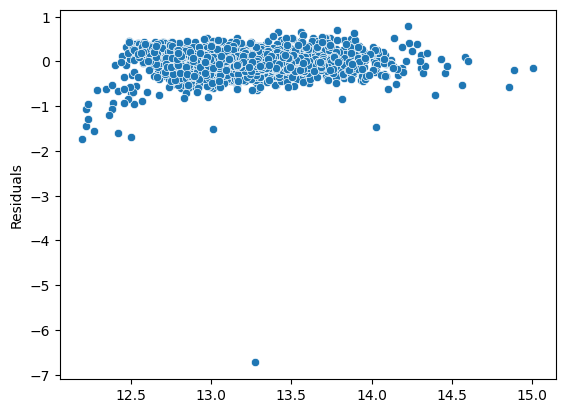

In [326]:
resids = y - cat_preds
sns.scatterplot(x=cat_preds, y=resids).set_ylabel("Residuals")

There is violation of linearity of this model. The scatterplot has systematic patterns, and the residuals are not randomly scattered around 0. Besides that, the extreme outlier of residuals spanning from 1 to -7 also cause the violation.

In [345]:
df_sorted = df.sort_values("resids")
df_sorted.head()

,Exterior Description,Directions,Fireplace Y/N,Irrigation Water Rights Y/N,Inclusions,Basement,Bedrooms Possible,Window Features,Land Lease Y/N,Garage Y/N,...,Longitude,log_price,log_house_size,log_HOA_fee,log_lot_size,log_Longitude,log_Latitude,price_per_sqft,house_age,resids
4385,NaN,NaN,Yes,No,"Dishwasher(s), Dryer(s), Refrigerator(s), Wash...",Finished,NaN,NaN,No,Yes,...,-122.524693,6.551080,7.488853,0.0,NaN,NaN,3.856420,0.391499,47,-6.725370
3851,NaN,WA-167 S and WA-512 W to Portland Ave E in Mid...,No,No,"Dryers, Refrigerators, Washers, SeeRemarks_, A...",NaN,2.0,NaN,NaN,NaN,...,-122.425882,10.463103,6.590301,0.0,NaN,NaN,3.853091,48.076923,49,-1.735431
3322,NaN,"From River Road head West, South on 35th. Go s...",Yes,No,"Dishwasher(s), Dryer(s), Refrigerator(s), Sewe...",NaN,3.0,NaN,NaN,NaN,...,-122.381764,10.819778,7.314553,0.0,NaN,NaN,3.855007,33.288948,50,-1.682672
1082,NaN,GPS doesn't work well. From 38th St make a rig...,No,No,"Dishwasher(s), Dryer(s), Refrigerator(s), Sewe...",NaN,2.0,NaN,NaN,NaN,...,-122.404356,10.819778,7.074963,0.0,NaN,NaN,3.854159,42.301184,35,-1.598201
1692,NaN,From Pac Ave to 136th. left on 136th. Left int...,No,No,"Awnings, Dishwasher(s), Dryer(s), Garbage Disp...",NaN,2.0,NaN,NaN,NaN,...,-122.432749,10.714418,6.828712,0.0,NaN,NaN,3.852984,48.701299,43,-1.556448


## Identify observations for which the model predicted poorly (i.e., they have large residuals). Determine if there appear to be any general patterns with houses for which the model is producing poor predictions. Can you think of anything that might help to address these issues?
The model predicted poorly with the largest residuals are rows 4385, 3851, 3322, 1082, and 1692.
The general patterns with houses include no HOA Fee, missing values in the log_lot_size,  are producing poor predictions.
My suggestion is that we can try using LASSO regression to handle many MLS Area dummy variables, reduce the overprediction issue by adding penalty item to help optimize the model.

# Model Interpretation
Do the following:

## Choose one quantitative variable in your model and interpret the coefficient for this variable in context.
Quantitative variable: Bathrooms
Coefficient: 0.0754
A one unit increase in Bathrooms results in an increase of 0.0754 in log_price, while holding beds, Latitude, Longitude, house_size, Lot Size Square Feet, Year Built, HOA Fee, County, MLS Area, Sewer, Cooling, Heating, Parking Features, and other variables constant.

## Choose one categorical variable in your model and interpret one of the coefficients for this categorical variable in context.
Categorical variable: MLS Area_14 - North Tacoma
Coefficient: 0.1469
An increase in MLS Area_14 - North Tacoma results in an increase of 0.1469 in log_price, while holding beds, Bathrooms, Latitude, Longitude, house_size, Lot Size Square Feet, Year Built, HOA Fee, County, Sewer, Cooling, Heating, Parking Features, and other variables constant.

In [332]:
print(X_cat.columns.tolist())

['beds', 'Bathrooms', 'Latitude', 'Longitude', 'house_size', 'Lot Size Square Feet', 'Year Built', 'HOA Fee', 'MLS Area_14 - North Tacoma', 'MLS Area_15 - North Tacoma', 'MLS Area_16 - North Tacoma', 'MLS Area_17 - North Tacoma', 'MLS Area_18 - North Tacoma', 'MLS Area_19 - North Tacoma', 'MLS Area_20 - North Tacoma', 'MLS Area_21 - North Tacoma', 'MLS Area_22 - North Tacoma', 'MLS Area_23 - North Tacoma', 'MLS Area_24 - North Tacoma', 'MLS Area_25 - North Tacoma', 'MLS Area_26 - Central Tacoma', 'MLS Area_27 - Central Tacoma', 'MLS Area_28 - Central Tacoma', 'MLS Area_29 - Central Tacoma', 'MLS Area_30 - Central Tacoma', 'MLS Area_31 - West Tacoma', 'MLS Area_32 - University Place', 'MLS Area_33 - University Place', 'MLS Area_34 - University Place', 'MLS Area_35 - University Place', 'MLS Area_36 - Lakewood', 'MLS Area_37 - Lakewood', 'MLS Area_38 - Lakewood', 'MLS Area_39 - Lakewood', 'MLS Area_43 - Steilacoom', 'MLS Area_45 - South Tacoma', 'MLS Area_46 - South Tacoma', 'MLS Area_47 

# Updating the Model
Finally, comment on anything that you might do to try to improve the model fit. Are there other predictors you would like to include? Are there other features you feel might be useful for improving the model?

You do not have to make the changes for this part of the project, but these ideas may be incorporated into the final version of the project.

In [340]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_cat, y, test_size=0.2)


In [341]:
train_model = LinearRegression()

train_model.fit(X_train, y_train)

test_preds = train_model.predict(X_test)

print("RMSE: ", root_mean_squared_error(y_test, test_preds))

RMSE:  0.18591572031648862


In [342]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)

lasso_CV_model = LassoCV(cv=10)
lasso_CV_model.fit(X_train_scaled, y_train)

lasso_CV_preds = lasso_CV_model.predict(X_test_scaled)

print("Selected alpha: ", lasso_CV_model.alpha_)
print("RMSE: ", root_mean_squared_error(y_test, lasso_CV_preds))

Selected alpha:  0.0020978100594247167
RMSE:  0.18600926352037117


After I tried the LASSO regression to see if there were any improvements, the RMSE of the LASSO model was 0.186 compared to 0.209 for the categorical model, which is better. LASSO adds LASSO penalty to prevent overfitting, and effectively handles the dummy variables created from categorical variables. Overall, the LASSO regression model is the best performing model.